### import libraries


In [13]:
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers , models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models  import load_model
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report
import os
os.getcwd()



'c:\\Users\\ASUS\\Desktop\\3mtt capstone project\\maize_cassava_disease_detactor'

In [14]:
train_data = tf.keras.utils.image_dataset_from_directory("dataset/cassava" , validation_split=0.2 , subset="training" , seed=123, image_size=(224 , 224) , batch_size=16  ,label_mode="categorical")
test_data = tf.keras.utils.image_dataset_from_directory("dataset/cassava" , validation_split=0.2 , subset="validation" , seed=123, image_size=(224 , 224) , batch_size=16 , label_mode="categorical" )

Found 21397 files belonging to 5 classes.
Using 17118 files for training.
Found 21397 files belonging to 5 classes.
Using 4279 files for validation.


In [15]:
model = keras.Sequential([
    keras.layers.Rescaling(1./255, input_shape=(224 , 224 , 3)),

    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),

    keras.layers.Conv2D(64 ,(3 , 3) ,  activation="relu"),
    keras.layers.MaxPooling2D((2 , 2)),
    keras.layers.Conv2D(128 ,(3 , 3) ,  activation="relu"),
    keras.layers.MaxPooling2D((2 , 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128 , activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(5 , activation="softmax")
])



c:\Users\ASUS\Desktop\3mtt capstone project\maize_cassava_disease_detactor\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

In [17]:
#model.compile(
#    optimizer = "Adam" ,
#    loss="categorical_crossentropy",
#    metrics=["accuracy"]
#)

In [18]:
#history = model.fit(
    # train_data , 
#  validation_data=test_data , 
#   epochs=15
#    )

cnn_model_load = (
    load_model("cassava_cnn_model.keras")

)
print("loaded successfull")

loaded successfull


In [19]:
#model.save("cassava_cnn_model.keras")
#print("model save succesfull")

In [20]:
class_names = [
    
    "Cassava___bacterial_blight" ,       
    "Cassava___brown_streak_disease" ,     
    " Cassava___green_mottle" ,      
    " Cassava___healthy"    ,  
    "Cassava___mosaic_disease" 
]

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 373248)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    47,775,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,852,165 (182.54 MB)

 Trainable params: 47,852,165 (182.54 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
y_true = []
y_predict = []

for images , labels in test_data:
    pred = model.predict(images , verbose=0)
    y_true.extend(np.argmax(labels.numpy() , axis=1))
    y_predict.extend(np.argmax(pred , axis=1))

print(classification_report(y_true,y_predict , target_names=class_names))

                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.04      0.92      0.09       189
Cassava___brown_streak_disease       0.00      0.00      0.00       422
        Cassava___green_mottle       0.00      0.00      0.00       488
             Cassava___healthy       0.00      0.00      0.00       522
      Cassava___mosaic_disease       0.61      0.09      0.16      2658

                      accuracy                           0.10      4279
                     macro avg       0.13      0.20      0.05      4279
                  weighted avg       0.38      0.10      0.10      4279



c:\Users\ASUS\Desktop\3mtt capstone project\maize_cassava_disease_detactor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\Desktop\3mtt capstone project\maize_cassava_disease_detactor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\Desktop\3mtt capstone project\maize_cassava_disease_detactor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa

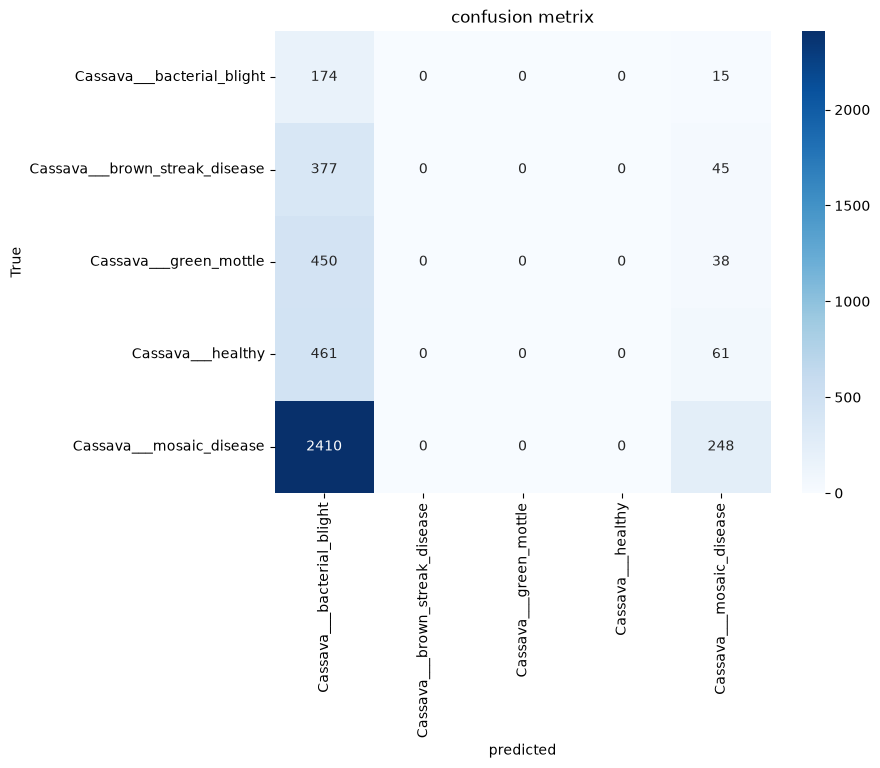

In [22]:
cm = confusion_matrix(y_true , y_predict)
plt.figure(figsize=(8,6))
sns.heatmap(cm , annot=True , fmt="d" , xticklabels=class_names , yticklabels=class_names , cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("True")
plt.title("confusion metrix")
plt.show()    

In [23]:
print("model input shape:" , model.input_shape)
print("class_names:" ,  class_names)

model input shape: (None, 224, 224, 3)
class_names: ['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', ' Cassava___green_mottle', ' Cassava___healthy', 'Cassava___mosaic_disease']


In [24]:
#def create_mobilenet_leaf_model():
    # Input tensor definition
 #   inputs = layers.Input(shape=(224, 224, 3), name="input_image")
    
    # Data Augmentation (applied during training on GPU)
  #  x = layers.RandomFlip("horizontal_and_vertical")(inputs)
   # x = layers.RandomRotation(0.2)(x)
    #x = layers.RandomZoom(0.1)(x)
    
    # MobileNetV2 expects pixel scaling between [-1, 1]
    #x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    
    # Load MobileNetV2 base without ImageNet's top 1000-class classifier
    #base_model = tf.keras.applications.MobileNetV2(
     #   input_shape=(224, 224, 3),
      #  include_top=False,
       # weights="imagenet"
   # )
    
    # FREEZE the base model weights so they are not changed during training
   # base_model.trainable = False
    
    # Forward pass through frozen base
    #x = base_model(x, training=False)
    
    # Custom Head for Leaf Disease Classification
    #x = layers.GlobalAveragePooling2D(name="avg_pooling")(x)
    #x = layers.Dropout(0.2, name="dropout")(x)
    #outputs = layers.Dense(class_names, activation="softmax", name="predictions")(x)
    
    # Combine into functional model
    #model = models.Model(inputs=inputs, outputs=outputs, name="Cassava_MobileNetV2")
    #return model

# 2. Build and compile
#model = create_mobilenet_leaf_model()

#model.compile(
 #   optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
  #  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
   # metrics=['accuracy'])